# Notebook 03: Feature Engineering & Train/Test Split

**Purpose:**
1. Create all derived financial features
2. Drop leakage and identifier columns
3. Perform stratified 80/20 train/test split
4. Save splits to `data/processed/`

**Critical design principles:**

**WHY feature engineering before the split:**
All derived features (loan_to_revenue_ratio, etc.) are computed from a single row's values — no aggregation across rows. This means there is NO data leakage risk from engineering before splitting. If we engineered after splitting, we would need to call the function twice with identical code — fragile and error-prone.

**WHY split before sklearn Pipeline fitting:**
The Pipeline's imputer and scaler must be fit ONLY on training data. If we fit them on all data before splitting, test data statistics (mean, std) contaminate the training process — classic data leakage. The sklearn Pipeline handles this correctly when called with `pipeline.fit(X_train, y_train)`.

**WHY stratified split:**
With class imbalance (e.g., 15% defaults), a random split could give a test set with 8% or 22% defaults by chance. Stratified split ensures both train and test have the same class ratio as the full dataset — essential for reliable evaluation metrics.

In [1]:
# ── CELL 1: Environment setup ──────────────────────────────────────────────────
import sys, os

try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/stanbic_sme_credit'
except ImportError:
    IN_COLAB = False
    _search = os.getcwd()
    BASE_PATH = _search
    for _ in range(3):
        if os.path.isdir(os.path.join(BASE_PATH, 'src')):
            break
        BASE_PATH = os.path.dirname(BASE_PATH)

sys.path.insert(0, os.path.join(BASE_PATH, 'src'))
env_str = 'Google Colab' if IN_COLAB else 'Local Jupyter'
print(f'Environment : {env_str}')
print(f'Base path   : {BASE_PATH}')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from preprocessing import (
    engineer_features, drop_non_model_columns,
    ALL_MODEL_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    BINARY_FEATURES, FAIRNESS_COLS, TARGET
)

pd.set_option('display.max_columns', 60)
FIGURES_PATH = f'{BASE_PATH}/reports/figures'
print('Environment ready.')

Mounted at /content/drive
Environment : Google Colab
Base path   : /content/drive/MyDrive/stanbic_sme_credit
Environment ready.


In [2]:
# ── CELL 2: Load cleaned data from interim/ ────────────────────────────────────
INTERIM_PATH = f'{BASE_PATH}/data/interim/cleaned_pre_split.csv'
df = pd.read_csv(INTERIM_PATH, low_memory=False)

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Target distribution:')
print(df[TARGET].value_counts())

Loaded: 3,037 rows x 39 columns
Target distribution:
loan_default
0    2634
1     403
Name: count, dtype: int64


## Step 1: Create Derived Features

In [3]:
# ── CELL 3: Run engineer_features() ───────────────────────────────────────────
# All 4 new v2 features are created here automatically via the updated
# preprocessing.py. No changes needed in this cell when new features are added
# — adding them to engineer_features() in preprocessing.py is sufficient.
# Cell 4 below validates and inspects all engineered features.

df_featured = engineer_features(df)

print(f'Shape after feature engineering: {df_featured.shape}')
print(f'New columns added ({df_featured.shape[1] - df.shape[1]}):')
new_cols = [c for c in df_featured.columns if c not in df.columns]
for c in new_cols:
    print(f'  {c}')

engineer_features: 22 new columns added
Shape after feature engineering: (3037, 61)
New columns added (22):
  loan_to_revenue_ratio
  collateral_coverage_ratio
  revenue_per_employee
  momo_to_revenue_ratio
  log_annual_revenue_ghs
  log_monthly_momo_volume_ghs
  log_avg_monthly_bank_balance_ghs
  log_loan_amount_requested_ghs
  log_collateral_value_ghs
  bureau_x_coverage
  revenue_per_year_log
  high_leverage_flag
  good_collateral_flag
  has_momo_and_tin
  repeat_borrower_flag
  credit_score_risk_flag
  momo_annual_to_loan
  previous_default_numeric
  bank_balance_to_loan_ratio
  formality_score
  unsecured_loan_flag
  sector_x_region


In [4]:
# ── CELL 4: Inspect engineered features ───────────────────────────────────────
# Feature lists are imported from preprocessing.py — single source of truth.
# ENGINEERED_NUMERIC here is just a local display list for validation output;
# the authoritative list for the sklearn pipeline is NUMERIC_FEATURES.

ENGINEERED_NUMERIC = [
    # Financial ratios
    'loan_to_revenue_ratio', 'collateral_coverage_ratio',
    'revenue_per_employee',  'momo_to_revenue_ratio',
    # Log-transformed financial columns
    'log_annual_revenue_ghs', 'log_loan_amount_requested_ghs',
    # Interaction features (v1)
    'bureau_x_coverage',     'revenue_per_year_log',
    # Cyclical date features
    'app_month_sin', 'app_month_cos', 'app_year',
    # Interaction features (v2) — verifiable cash flow and repayment capacity
    'momo_annual_to_loan',      # verifiable digital cash flow vs loan size
    'bank_balance_to_loan_ratio', # monthly cash reserves / loan amount
    # Composite signals (v3)
    'formality_score',          # 0-3: has_tin + has_momo + has_bureau (formal economy integration)
    # Ordinal signals
    'previous_default_numeric',   # 1.0=Yes / 0.5=Unknown / 0.0=No
]

ENGINEERED_BINARY = [
    'high_leverage_flag', 'good_collateral_flag',
    'has_momo_and_tin',  'repeat_borrower_flag',
    'credit_score_risk_flag',
    'unsecured_loan_flag',  # v3: 1 if collateral is None/Guarantor Only
]

print('ENGINEERED NUMERIC FEATURES — descriptive statistics:')
print(df_featured[ENGINEERED_NUMERIC].describe().T.round(3).to_string())

print()
print('NEW FEATURES — default rate correlation:')
check_features = [
    'momo_annual_to_loan', 'formality_score',
    'previous_default_numeric', 'bank_balance_to_loan_ratio',
]
for feat in check_features:
    if feat in df_featured.columns:
        median_default    = df_featured[df_featured[TARGET]==1][feat].median()
        median_no_default = df_featured[df_featured[TARGET]==0][feat].median()
        direction = 'LOWER for defaulters' if median_default < median_no_default else 'HIGHER for defaulters'
        print(f'  {feat:<35}  median(default)={median_default:.3f}  '
              f'median(no default)={median_no_default:.3f}  => {direction}')

print()
print('ENGINEERED BINARY FLAGS — default rate by flag value:')
for flag in ENGINEERED_BINARY:
    if flag in df_featured.columns:
        rate_0 = df_featured[df_featured[flag]==0][TARGET].mean()
        rate_1 = df_featured[df_featured[flag]==1][TARGET].mean()
        n_1    = int((df_featured[flag]==1).sum())
        lift   = rate_1 / rate_0 if rate_0 > 0 else float('nan')
        print(f'  {flag:<25}  flag=0 default {rate_0:.1%}  |  flag=1 default {rate_1:.1%}  '
              f'|  lift={lift:.2f}x  (n_flag1={n_1})')

ENGINEERED NUMERIC FEATURES — descriptive statistics:
                                count       mean         std       min       25%       50%        75%          max
loan_to_revenue_ratio          2950.0      3.274      20.606     0.001     0.119     0.405      1.378      589.189
collateral_coverage_ratio      2648.0      3.769      10.283     0.000     0.000     0.899      3.283      281.438
revenue_per_employee           2950.0  43166.018  180534.974     6.534  2215.040  7889.783  28742.887  6828782.270
momo_to_revenue_ratio          2950.0      5.206      31.667     0.000     0.071     0.494      2.048     1018.473
log_annual_revenue_ghs         3037.0     10.535       2.379     0.000     9.737    10.836     11.861       16.067
log_loan_amount_requested_ghs  3037.0      9.979       0.999     6.347     9.293     9.972     10.671       13.611
bureau_x_coverage              3037.0   1796.521    5531.776     0.000     0.000   308.106   1491.255   181527.572
revenue_per_year_log      

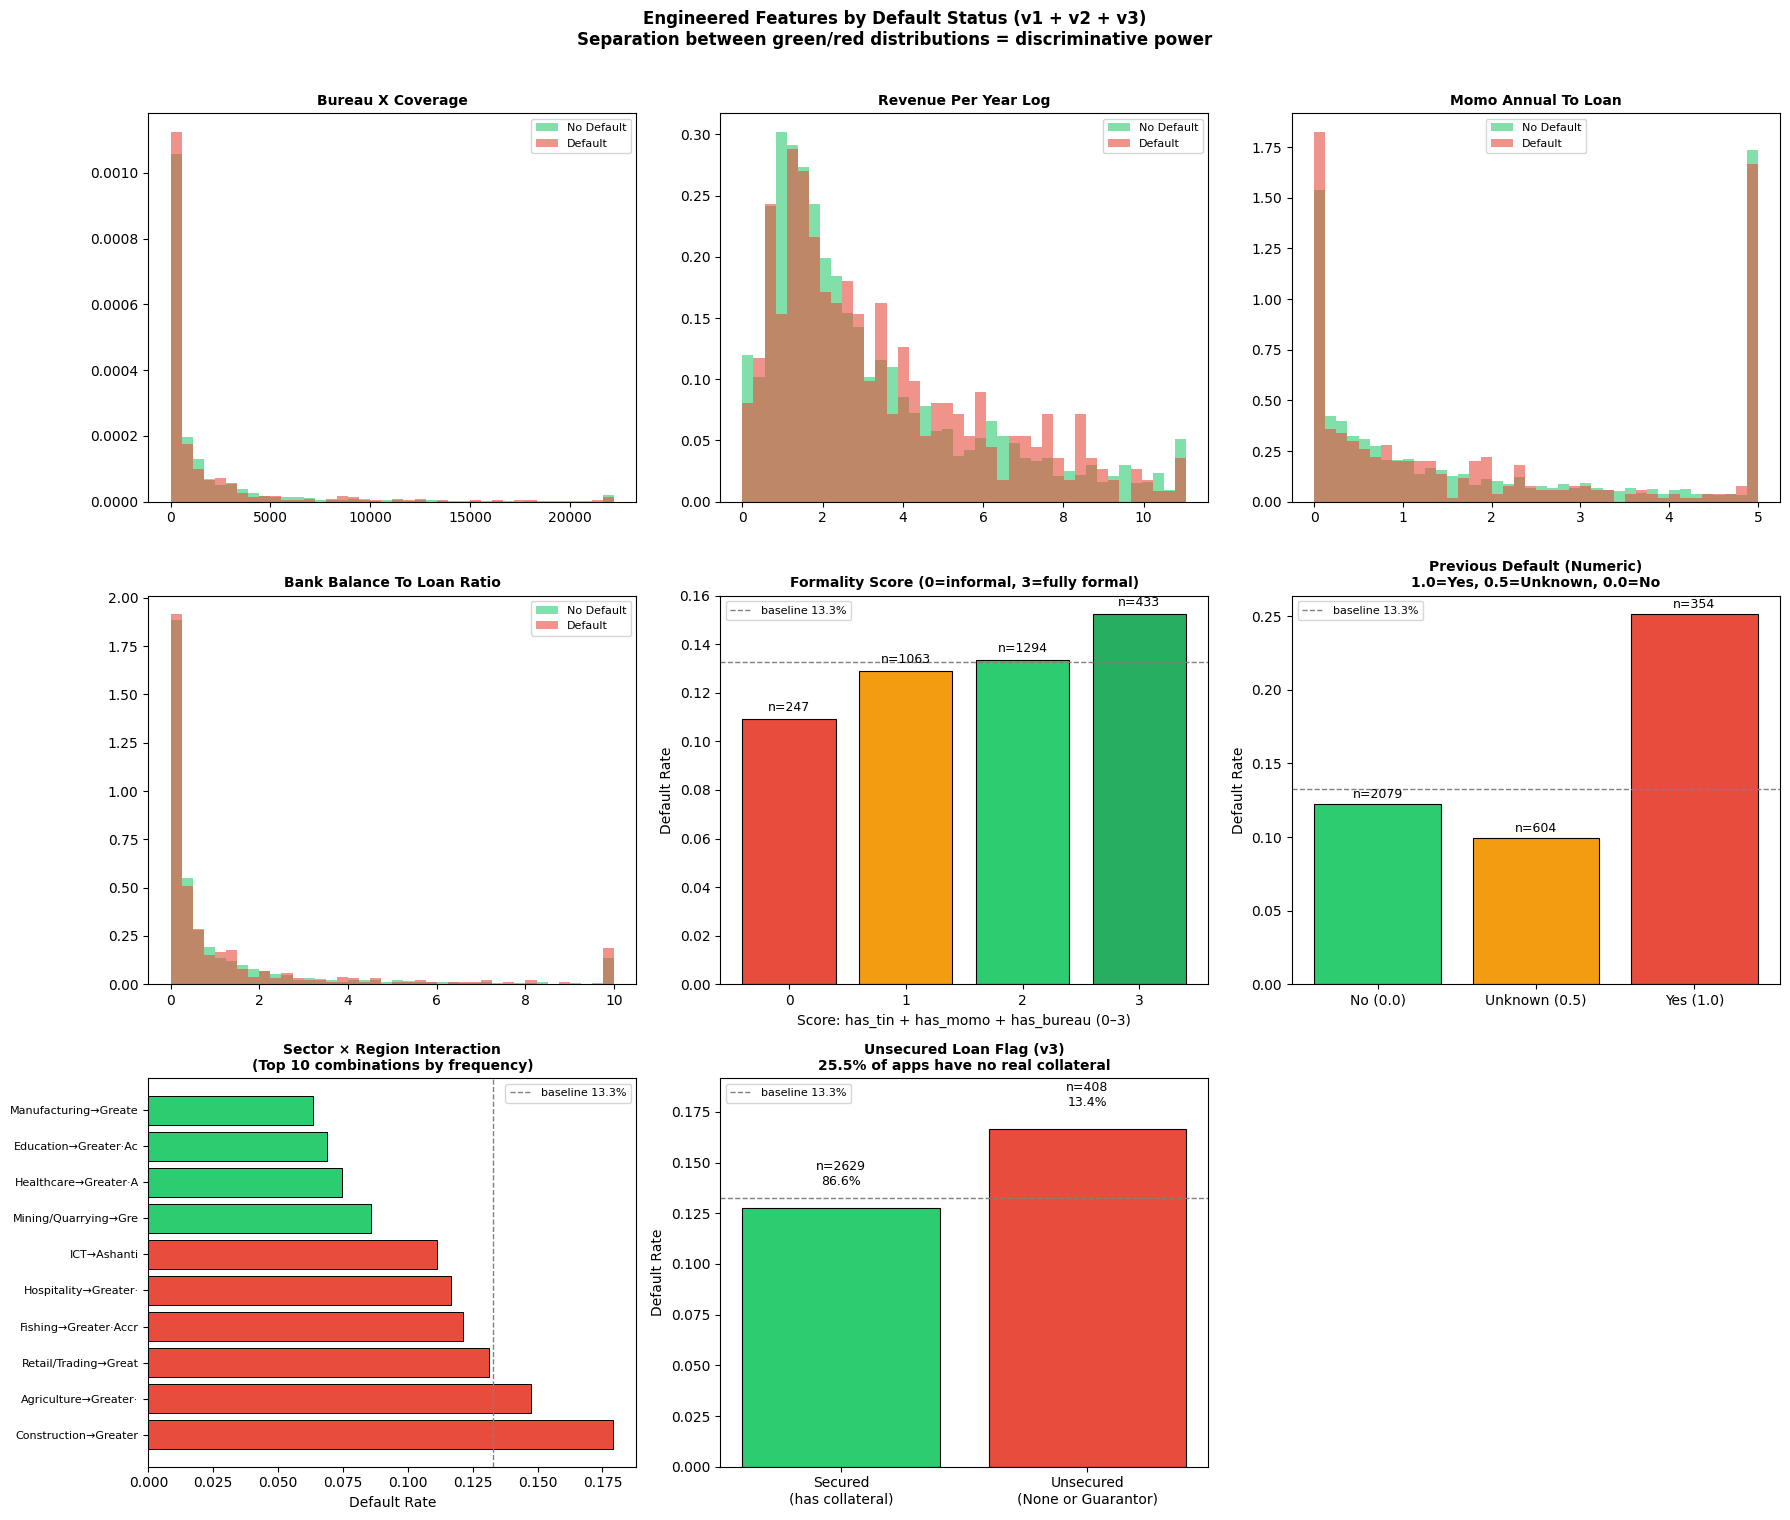

Saved: 09b_new_features_v3.png

KEY v3 FEATURE RATIONALE:
  formality_score ---------- composite signal: integration into formal economy (0-3)
  unsecured_loan_flag ------ 25.5% of apps lack real collateral → explicit risk flag
  sector_x_region ---------- regional sector dynamics (e.g., Retail in Savannah vs Accra)
  previous_default_numeric  ordinal 1/0.5/0: preserves full signal vs TargetEncoder shrinkage


In [5]:
# ── CELL 5b: Visualise new interaction features (v1 + v2 + v3) ───────────────
def _finite(series):
    return series[series.notna() & series.apply(lambda x: x not in [float('inf'), float('-inf')])]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Row 1: v1 + early v2 continuous interaction features
for ax, col in zip(axes[0], ['bureau_x_coverage', 'revenue_per_year_log',
                               'momo_annual_to_loan']):
    data_0 = _finite(df_featured[df_featured[TARGET]==0][col].dropna())
    data_1 = _finite(df_featured[df_featured[TARGET]==1][col].dropna())
    combined = pd.concat([data_0, data_1])
    cap = combined.quantile(0.99) if len(combined) > 0 else 1.0
    floor = combined.quantile(0.01) if len(combined) > 0 else 0.0
    ax.hist(data_0.clip(lower=floor, upper=cap), bins=40, alpha=0.6,
            label='No Default', color='#2ecc71', density=True)
    ax.hist(data_1.clip(lower=floor, upper=cap), bins=40, alpha=0.6,
            label='Default', color='#e74c3c', density=True)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

# Row 2: bank_balance_to_loan_ratio, formality_score, previous_default_numeric
for ax, col in zip(axes[1], ['bank_balance_to_loan_ratio', 'formality_score',
                               'previous_default_numeric']):
    if col == 'formality_score':
        # Discrete 0-3: bar chart of default rate by score
        rates  = df_featured.groupby(col)[TARGET].mean()
        counts = df_featured.groupby(col)[TARGET].count()
        bar_colors = ['#e74c3c', '#f39c12', '#2ecc71', '#27ae60'][:len(rates)]
        bars = ax.bar(rates.index.astype(str), rates.values,
                      color=bar_colors, edgecolor='black', linewidth=0.8)
        for bar, (idx, cnt) in zip(bars, counts.items()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'n={cnt}', ha='center', va='bottom', fontsize=9)
        ax.set_title('Formality Score (0=informal, 3=fully formal)', fontsize=10, fontweight='bold')
        ax.set_ylabel('Default Rate')
        ax.axhline(df_featured[TARGET].mean(), ls='--', color='gray', lw=1,
                   label=f'baseline {df_featured[TARGET].mean():.1%}')
        ax.legend(fontsize=8)
        ax.set_xlabel('Score: has_tin + has_momo + has_bureau (0–3)')
    elif col == 'previous_default_numeric':
        # Discrete 0.0/0.5/1.0: bar chart of default rate
        rates  = df_featured.groupby(col)[TARGET].mean()
        counts = df_featured.groupby(col)[TARGET].count()
        labels = {0.0: 'No (0.0)', 0.5: 'Unknown (0.5)', 1.0: 'Yes (1.0)'}
        bar_colors = ['#2ecc71', '#f39c12', '#e74c3c']
        bars = ax.bar([labels.get(i, str(i)) for i in rates.index], rates.values,
                      color=bar_colors[:len(rates)], edgecolor='black', linewidth=0.8)
        for bar, (idx, cnt) in zip(bars, counts.items()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'n={cnt}', ha='center', va='bottom', fontsize=9)
        ax.set_title('Previous Default (Numeric)\n1.0=Yes, 0.5=Unknown, 0.0=No',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('Default Rate')
        ax.axhline(df_featured[TARGET].mean(), ls='--', color='gray', lw=1,
                   label=f'baseline {df_featured[TARGET].mean():.1%}')
        ax.legend(fontsize=8)
    else:
        # Continuous: histogram
        data_0 = _finite(df_featured[df_featured[TARGET]==0][col].dropna())
        data_1 = _finite(df_featured[df_featured[TARGET]==1][col].dropna())
        combined = pd.concat([data_0, data_1])
        cap   = combined.quantile(0.99) if len(combined) > 0 else 1.0
        floor = combined.quantile(0.01) if len(combined) > 0 else 0.0
        ax.hist(data_0.clip(lower=floor, upper=cap), bins=40, alpha=0.6,
                label='No Default', color='#2ecc71', density=True)
        ax.hist(data_1.clip(lower=floor, upper=cap), bins=40, alpha=0.6,
                label='Default', color='#e74c3c', density=True)
        ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)

# Row 3: sector_x_region (categorical interaction), and unsecured_loan_flag
# sector_x_region is too high-cardinality (192 combinations) for a distribution plot
# Show top 10 most common sector_x_region with default rates instead
ax = axes[2][0]
if 'sector_x_region' in df_featured.columns:
    top_sr = df_featured['sector_x_region'].value_counts().head(10).index
    sr_data = df_featured[df_featured['sector_x_region'].isin(top_sr)]
    rates = sr_data.groupby('sector_x_region')[TARGET].mean().sort_values(ascending=False)
    bar_colors = ['#e74c3c' if v > sr_data[TARGET].mean() else '#2ecc71' for v in rates.values]
    bars = ax.barh(range(len(rates)), rates.values, color=bar_colors, edgecolor='black', linewidth=0.7)
    ax.set_yticks(range(len(rates)))
    ax.set_yticklabels([label.replace('_', '→').replace(' ', '·')[:20] for label in rates.index], fontsize=8)
    ax.set_xlabel('Default Rate')
    ax.set_title('Sector × Region Interaction\n(Top 10 combinations by frequency)', fontsize=10, fontweight='bold')
    ax.axvline(df_featured[TARGET].mean(), ls='--', color='gray', lw=1,
               label=f'baseline {df_featured[TARGET].mean():.1%}')
    ax.legend(fontsize=8)

# unsecured_loan_flag: bar chart of default rate
ax = axes[2][1]
if 'unsecured_loan_flag' in df_featured.columns:
    rates  = df_featured.groupby('unsecured_loan_flag')[TARGET].mean()
    counts = df_featured.groupby('unsecured_loan_flag')[TARGET].count()
    bar_colors = ['#2ecc71', '#e74c3c']
    bars = ax.bar(['Secured\n(has collateral)', 'Unsecured\n(None or Guarantor)'],
                  rates.values, color=bar_colors, edgecolor='black', linewidth=0.8)
    for bar, (idx, cnt) in zip(bars, counts.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'n={cnt}\n{cnt/len(df_featured):.1%}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Default Rate')
    ax.set_title('Unsecured Loan Flag (v3)\n25.5% of apps have no real collateral', fontsize=10, fontweight='bold')
    ax.axhline(df_featured[TARGET].mean(), ls='--', color='gray', lw=1,
               label=f'baseline {df_featured[TARGET].mean():.1%}')
    ax.set_ylim(0, max(rates.values) * 1.15)
    ax.legend(fontsize=8)

axes[2][2].axis('off')  # placeholder

plt.suptitle('Engineered Features by Default Status (v1 + v2 + v3)\n'
             'Separation between green/red distributions = discriminative power',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/09b_new_features_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09b_new_features_v3.png')
print()
print('KEY v3 FEATURE RATIONALE:')
print('  formality_score ---------- composite signal: integration into formal economy (0-3)')
print('  unsecured_loan_flag ------ 25.5% of apps lack real collateral → explicit risk flag')
print('  sector_x_region ---------- regional sector dynamics (e.g., Retail in Savannah vs Accra)')
print('  previous_default_numeric  ordinal 1/0.5/0: preserves full signal vs TargetEncoder shrinkage')

In [6]:
# ── CELL 6: Loan-to-Revenue ratio analysis (also feeds hard rule R004) ────────
ltr = df_featured['loan_to_revenue_ratio']
print('LOAN-TO-REVENUE RATIO ANALYSIS')
print(f'  Median: {ltr.median():.2f}')
print(f'  Mean:   {ltr.mean():.2f}')
print(f'  > 1x (loan > annual revenue): {(ltr > 1).sum():,} ({(ltr > 1).mean():.1%})')
print(f'  > 3x: {(ltr > 3).sum():,} ({(ltr > 3).mean():.1%})')
print(f'  > 5x (Hard Rule R004 triggers): {(ltr > 5).sum():,} ({(ltr > 5).mean():.1%})')
print()
print('Default rate by loan-to-revenue bucket:')
df_featured['ltr_bucket'] = pd.cut(ltr.fillna(0), bins=[0, 0.5, 1, 2, 5, 100],
                                    labels=['<0.5x', '0.5-1x', '1-2x', '2-5x', '>5x'])
print(df_featured.groupby('ltr_bucket', observed=True)[TARGET].agg(['mean', 'count']).to_string())

LOAN-TO-REVENUE RATIO ANALYSIS
  Median: 0.41
  Mean:   3.27
  > 1x (loan > annual revenue): 914 (30.1%)
  > 3x: 417 (13.7%)
  > 5x (Hard Rule R004 triggers): 277 (9.1%)

Default rate by loan-to-revenue bucket:
                mean  count
ltr_bucket                 
<0.5x       0.127182   1604
0.5-1x      0.152778    432
1-2x        0.131098    328
2-5x        0.158576    309
>5x         0.117871    263


## Step 2: Select and Verify Final Feature Sets

In [7]:
# ── CELL 7: Confirm all model features are present ────────────────────────────
missing_features = [f for f in ALL_MODEL_FEATURES if f not in df_featured.columns]
if missing_features:
    print(f'WARNING: Missing features: {missing_features}')
else:
    print(f'All {len(ALL_MODEL_FEATURES)} model features present.')

print(f'\nNUMERIC_FEATURES ({len(NUMERIC_FEATURES)}):',  NUMERIC_FEATURES)
print(f'\nCATEGORICAL_FEATURES ({len(CATEGORICAL_FEATURES)}):', CATEGORICAL_FEATURES)
print(f'\nBINARY_FEATURES ({len(BINARY_FEATURES)}):', BINARY_FEATURES)
print(f'\nFAIRNESS_COLS (NOT in model):', FAIRNESS_COLS)

All 41 model features present.

NUMERIC_FEATURES (24): ['years_in_operation', 'owner_age', 'num_employees', 'log_annual_revenue_ghs', 'log_monthly_momo_volume_ghs', 'log_avg_monthly_bank_balance_ghs', 'bank_account_tenure_months', 'log_loan_amount_requested_ghs', 'log_collateral_value_ghs', 'credit_bureau_score_imputed', 'previous_loan_count', 'loan_to_revenue_ratio', 'collateral_coverage_ratio', 'revenue_per_employee', 'momo_to_revenue_ratio', 'app_month_sin', 'app_month_cos', 'app_year', 'bureau_x_coverage', 'revenue_per_year_log', 'momo_annual_to_loan', 'bank_balance_to_loan_ratio', 'previous_default_numeric', 'formality_score']

CATEGORICAL_FEATURES (6): ['sector', 'region', 'loan_purpose', 'collateral_type', 'previous_default_clean', 'sector_x_region']

BINARY_FEATURES (11): ['has_momo_account', 'has_tin', 'has_credit_bureau_score', 'has_previous_loan_history', 'tenure_is_zero_flag', 'high_leverage_flag', 'good_collateral_flag', 'has_momo_and_tin', 'repeat_borrower_flag', 'credit_

## Step 3: Stratified Train / Test Split

**Why 80/20:** With 3,036 rows and ~15% default rate, the test set has ~607 rows with ~91 positives — borderline stable for AUC estimation. If the default rate is lower, consider 85/15.

**Why random_state=42:** Reproducibility convention. Any collaborator re-running the code gets the same split.

**Why keep fairness columns separate:** We do not feed them into the model, but we need them in notebook 07 to audit whether the model produces equitable outcomes across demographic groups.

In [8]:
# ── CELL 8: Prepare feature matrix X and target y ─────────────────────────────
X = df_featured[ALL_MODEL_FEATURES].copy()
y = df_featured[TARGET].copy()

# Fairness columns saved separately — NOT part of X
fairness_available = [c for c in FAIRNESS_COLS if c in df_featured.columns]
fairness_df = df_featured[fairness_available].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y distribution: {y.value_counts().to_dict()}')
print(f'fairness_df columns: {list(fairness_df.columns)}')
print(f'Missing values in X: {X.isnull().sum().sum():,} (to be imputed by sklearn Pipeline)')

X shape: (3037, 41)
y shape: (3037,)
y distribution: {0: 2634, 1: 403}
fairness_df columns: ['ethnic_group', 'owner_gender', 'disability_status', 'owner_gender_clean']
Missing values in X: 1,058 (to be imputed by sklearn Pipeline)


In [9]:
# ── CELL 9: Stratified 80/20 split ────────────────────────────────────────────
# CRITICAL: stratify=y ensures both train and test sets have the same
# class ratio as the full dataset. Without this, one set might have
# too few positives for reliable AUC estimation.

X_train, X_test, y_train, y_test, fair_train, fair_test = train_test_split(
    X, y, fairness_df,
    test_size=0.20,
    random_state=42,
    stratify=y        # ← preserves class ratio
)

print('SPLIT RESULTS:')
print(f'  Training set : {len(X_train):,} rows  ({len(X_train)/len(X):.0%})')
print(f'  Test set     : {len(X_test):,} rows  ({len(X_test)/len(X):.0%})')
print()
print('CLASS RATIO VERIFICATION (stratification check):')
print(f'  Full dataset : {y.mean():.4f} ({y.mean():.2%} default rate)')
print(f'  Training set : {y_train.mean():.4f} ({y_train.mean():.2%} default rate)')
print(f'  Test set     : {y_test.mean():.4f} ({y_test.mean():.2%} default rate)')
print()
print(f'  Positives in test set: {y_test.sum()} (need ≥80 for stable AUC estimation)')

# Verify stratification worked
rate_diff = abs(y_train.mean() - y_test.mean())
assert rate_diff < 0.005, f'Stratification failed! Rate diff: {rate_diff:.4f}'
print('PASS: stratification successful')

SPLIT RESULTS:
  Training set : 2,429 rows  (80%)
  Test set     : 608 rows  (20%)

CLASS RATIO VERIFICATION (stratification check):
  Full dataset : 0.1327 (13.27% default rate)
  Training set : 0.1326 (13.26% default rate)
  Test set     : 0.1332 (13.32% default rate)

  Positives in test set: 81 (need ≥80 for stable AUC estimation)
PASS: stratification successful


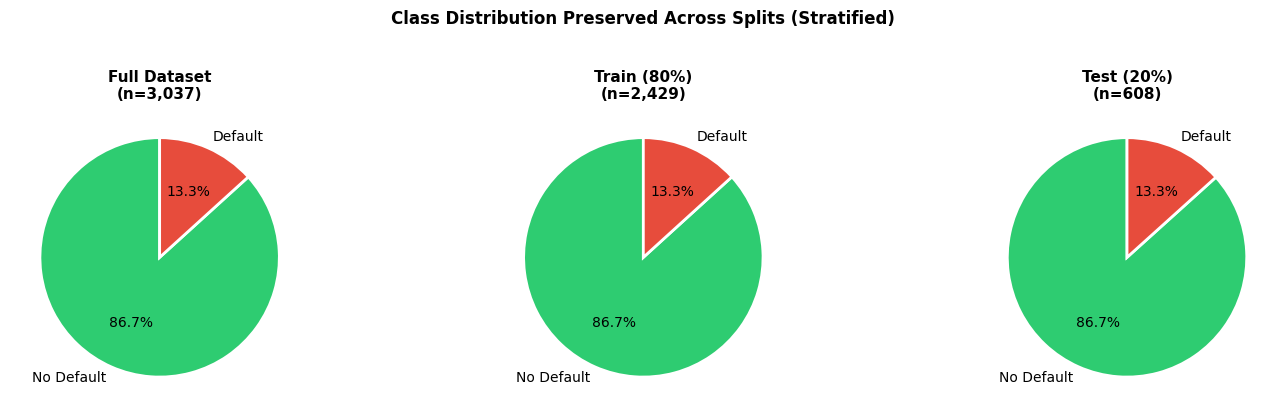

In [10]:
# ── CELL 10: Visualise train/test split ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sets = [('Full Dataset', y), ('Train (80%)', y_train), ('Test (20%)', y_test)]
for ax, (label, data) in zip(axes, sets):
    counts = data.value_counts().sort_index()
    ax.pie(counts, labels=['No Default', 'Default'],
           colors=['#2ecc71', '#e74c3c'],
           autopct='%1.1f%%', startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(f'{label}\n(n={len(data):,})', fontsize=11, fontweight='bold')

plt.suptitle('Class Distribution Preserved Across Splits (Stratified)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/10_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Save All Splits to `data/processed/`

In [11]:
# ── CELL 11: Save processed splits ────────────────────────────────────────────
PROCESSED = f'{BASE_PATH}/data/processed'

X_train.to_csv(f'{PROCESSED}/X_train.csv', index=True)
X_test.to_csv(f'{PROCESSED}/X_test.csv',  index=True)
y_train.to_csv(f'{PROCESSED}/y_train.csv', index=True, header=True)
y_test.to_csv(f'{PROCESSED}/y_test.csv',  index=True, header=True)
fair_train.to_csv(f'{PROCESSED}/fair_train.csv', index=True)
fair_test.to_csv(f'{PROCESSED}/fair_test.csv',   index=True)

print('Saved to data/processed/:')
print(f'  X_train.csv  : {X_train.shape}')
print(f'  X_test.csv   : {X_test.shape}')
print(f'  y_train.csv  : {y_train.shape}')
print(f'  y_test.csv   : {y_test.shape}')
print(f'  fair_train.csv: {fair_train.shape}')
print(f'  fair_test.csv : {fair_test.shape}')
print()

# Also save key metadata for downstream notebooks
import json
metadata = {
    'n_train':              int(len(X_train)),
    'n_test':               int(len(X_test)),
    'default_rate_full':    float(y.mean()),
    'default_rate_train':   float(y_train.mean()),
    'default_rate_test':    float(y_test.mean()),
    'n_positives_train':    int(y_train.sum()),
    'n_positives_test':     int(y_test.sum()),
    'n_features':           int(X_train.shape[1]),
    'numeric_features':     NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'binary_features':      BINARY_FEATURES,
    'scale_pos_weight':     float((y_train == 0).sum() / (y_train == 1).sum()),
    'random_state':         42
}
with open(f'{PROCESSED}/split_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved: split_metadata.json')
print(f'  scale_pos_weight for XGBoost: {metadata["scale_pos_weight"]:.2f}')
print()
print('Proceed to notebook 04_modeling.ipynb')

Saved to data/processed/:
  X_train.csv  : (2429, 41)
  X_test.csv   : (608, 41)
  y_train.csv  : (2429,)
  y_test.csv   : (608,)
  fair_train.csv: (2429, 4)
  fair_test.csv : (608, 4)

Saved: split_metadata.json
  scale_pos_weight for XGBoost: 6.54

Proceed to notebook 04_modeling.ipynb
